###  Cell 1: 导入所有必需的库


In [1]:
import cv2
import numpy as np
import pandas as pd
import h5py
import tarfile
import os
import shutil
import datetime as dt
from math import *
from tqdm.notebook import tqdm # 用于在 Jupyter 中显示漂亮的进度条
import matplotlib.pyplot as plt
import calendar
import h5py



### Cell 2: 路径配置与全局参数

In [ ]:
# 1. 设置你本地的路径 (请根据实际情况修改)
project_path = os.getcwd()  # 你的项目主目录
tar_folder = os.path.join(project_path, '2019StanFord_image') # 存放所有单月 tar 包的文件夹
pv_data_path = os.path.join(project_path, 'pv_data', 'pv_output_valid.pkl') # PV 数据文件
output_folder=r"E:\造数据集\output_folder"
os.makedirs(output_folder, exist_ok=True)
output_h5_path =os.path.join(output_folder, '2019_dataset_dual.h5')
# 2. 图像处理参数

# 3.  Train/Test 划分标准
start_date = dt.datetime(2019,1,1) 
end_date = dt.datetime(2020,1,1) 

sunny_day = [(2019,1,25),(2019,5,31),(2019,6,23),(2019,7,14),(2019,8,11),(2019,9,6),(2019,10,14)]
#晴天：1.25、2无、5.31、6.23、7.14、8.11、9.6、10.14
cloudy_day = [(2019,1,31),(2019,5,27),(2019,6,28),(2019,7,21),(2019,8,10),(2019,9,7),(2019,10,19)]
#多云：1.31、2不、5.27、6.28、7.21、8.10、9.7、10.19
sunny_datetime = [dt.datetime(day[0],day[1],day[2]) for day in sunny_day]
cloudy_datetime = [dt.datetime(day[0],day[1],day[2]) for day in cloudy_day]
typical_dates = sunny_datetime + cloudy_datetime

print(f"配置文件加载完成！共设置了 {len(typical_dates)} 个典型日期。")

配置文件加载完成！共设置了 14 个测试集天数。


### Cell 3: 太阳位置

In [3]:
def doy_tod_conv(date_and_time, longitude=-122.174199, time_zone_center_longitude=-120):
    # 原作者的时间转换逻辑（保持不变，处理夏令时和经度偏差）
    pst_center_longitude = time_zone_center_longitude 
    loc_longitude = longitude 
    correction = np.abs(60/15*(loc_longitude - pst_center_longitude))
    min_correction = int(correction) 
    sec_correction = int((correction - min_correction)*60)  
    if date_and_time.minute<=min_correction:
        date_and_time= date_and_time.replace(hour = date_and_time.hour-1, minute=60+date_and_time.minute-min_correction-1, second=60-sec_correction)
    else:
        date_and_time = date_and_time.replace(minute=date_and_time.minute-min_correction-1, second=60-sec_correction)
    
    time_of_day = date_and_time.hour * 3600 + date_and_time.minute * 60 + date_and_time.second
    
    months = [31,28,31,30,31,30,31,31,30,31,30,31] 
    if (date_and_time.year % 4 == 0) and (date_and_time.year % 100 != 0 or date_and_time.year % 400 ==0 ):
        months[1] = 29 
    day_of_year = sum(months[:date_and_time.month-1]) + date_and_time.day
    
    #处理夏令时（-3600s），但是看输出有问题，注释掉试试
    dst_start_day = sum(months[:2]) + calendar.monthcalendar(date_and_time.year,3)[1][6] 
    dst_end_day = sum(months[:10]) + calendar.monthcalendar(date_and_time.year,11)[0][6]
    if day_of_year >= dst_start_day and day_of_year < dst_end_day:
        time_of_day = time_of_day - 3600
    

    return day_of_year, time_of_day

def solar_angle(times, latitude=37.424107, longitude=-122.174199, time_zone_center_longitude=-120):
    # 计算太阳的方位角和天顶角
    day_of_year, time_of_day = doy_tod_conv(times, longitude, time_zone_center_longitude)
    latitude = radians(latitude) 

    # ==========================================
    # 🌟 核心升级：均时差 (Equation of Time) 分钟修正项
    # 将机械的手表时间，修正为宇宙真实的“太阳时间”
    # ==========================================
    # B 是以弧度表示的平近点角 (2019年春分点在第 80 天)
    B = 2 * pi * (day_of_year - 80) / 365.0
    
    # 国际标准 EoT 近似公式 (计算出需要补偿的分钟数)
    eot_minutes = 9.87 * sin(2 * B) - 7.53 * cos(B) - 1.5 * sin(B)
    
    # 将算出的分钟数转化为秒，加到原有的 time_of_day 上！
    time_of_day_corrected = time_of_day + (eot_minutes * 60)
    # ==========================================

    alpha = 2*pi*(time_of_day_corrected-43200)/86400 #计算真实太阳时
    delta = radians(23.44*sin(radians((360/365.25)*(day_of_year-80))))
    chi = acos(sin(delta)*sin(latitude)+cos(delta)*cos(latitude)*cos(alpha))
    
    tan_xi = sin(alpha)/(sin(latitude)*cos(alpha)-cos(latitude)*tan(delta)) 
    if alpha>0 and tan_xi>0:
        xi = pi+atan(tan_xi)
    elif alpha>0 and tan_xi<0:
        xi = 2*pi+atan(tan_xi)
    elif alpha<0 and tan_xi>0:
        xi = atan(tan_xi)
    else:
        xi = pi+atan(tan_xi)
    return degrees(xi), degrees(chi)


""" # 1.  7 个晴天基准日 (代表 7 个月)
sunny_days = [
    "20190125", "20190526", "20190604", 
    "20190714", "20190814", "20190906", "20191014"
]
 """
def get_theo_sun_position(time_obj):
    """最纯净的天文理论坐标"""
    delta = 14.036 
    r = 928         
    origin_y = 928  
    origin_x = 960  
    azimuth, zenith = solar_angle(time_obj) 
    rho = zenith / 90 * r 
    theta = azimuth - delta + 90 
    theo_y = origin_y - rho * sin(radians(theta))
    theo_x = origin_x + rho * cos(radians(theta))
    return int(round(theo_x)), int(round(theo_y))

# 用于存储终极插值台账
MONTHLY_INTERP_TABLE = {}

for idx, target_date in enumerate(sunny_day):
    year,month,day = target_date
    month_str = f"{month:02d}"
    month_int = month
    date_str = f"{year}{month_str}{day:02d}"

    tar_name = f"2019_{month_str}_images_raw.tar"
    tar_path = os.path.join(tar_folder, tar_name)
    
    if not os.path.exists(tar_path):
        print(f"跳过 {target_date}，找不到对应的 tar 包")
        continue
        
    time_floats = []
    dx_list = []
    dy_list = []
    
    with tarfile.open(tar_path, "r") as tar:
        members = tar.getmembers()
        day_members = [m for m in members if m.name.endswith('.jpg') and date_str in m.name]
        day_members.sort(key=lambda x: os.path.basename(x.name))
        
        # 每隔 15 张图（约十来分钟）采样一次
        for m in day_members[::15]:
            filename = os.path.basename(m.name)
            curr_time = dt.datetime.strptime(filename.split('.')[0], '%Y%m%d%H%M%S')
            
            # 只截取白天 07:00 到 18:30 的数据
            if curr_time.hour < 7 or (curr_time.hour == 18 and curr_time.minute > 30) or curr_time.hour > 18:
                continue
                
            f = tar.extractfile(m)
            img_array = np.asarray(bytearray(f.read()), dtype=np.uint8)
            img_raw = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
            gray = cv2.cvtColor(img_raw, cv2.COLOR_BGR2GRAY)
            
            theo_x, theo_y = get_theo_sun_position(curr_time)
            
            # 局部视觉提取真实中心 (抗眩光版)
            search_radius = 120
            
            # 防止越界
            if theo_y - search_radius < 0 or theo_y + search_radius > 2048 or theo_x - search_radius < 0 or theo_x + search_radius > 2048:
                continue
                
            roi = gray[theo_y - search_radius : theo_y + search_radius, 
                       theo_x - search_radius : theo_x + search_radius]
            
            _, thresh = cv2.threshold(roi, 245, 255, cv2.THRESH_BINARY)
            kernel = np.ones((7, 7), np.uint8)
            eroded = cv2.erode(thresh, kernel, iterations=2)
            contours, _ = cv2.findContours(eroded, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            if contours:
                largest_contour = max(contours, key=cv2.contourArea)
                # 过滤太小的噪点
                if cv2.contourArea(largest_contour) > 50:
                    (cX_local, cY_local), _ = cv2.minEnclosingCircle(largest_contour)
                    
                    real_x = theo_x - search_radius + cX_local
                    real_y = theo_y - search_radius + cY_local
                    
                    dx = real_x - theo_x
                    dy = real_y - theo_y
                    
                    time_float = curr_time.hour + curr_time.minute / 60.0 + curr_time.second / 3600.0
                    
                    time_floats.append(round(time_float, 3))
                    dx_list.append(round(dx, 1))
                    dy_list.append(round(dy, 1))
    
    # 存入字典
    if time_floats:
        MONTHLY_INTERP_TABLE[month_int] = {
            'times': time_floats,
            'dx': dx_list,
            'dy': dy_list
        }

"""         # 打印最终输出字典，方便复制
    print("\n" + "="*60)
    print("时序插值台账提取完毕！将下方输出复制保存：\n")
    print("MONTHLY_INTERP_TABLE = {")
    for m, data in MONTHLY_INTERP_TABLE.items():
        print(f"    {m}: {{")
        print(f"        'times': {data['times']},")
        print(f"        'dx': {data['dx']},")
        print(f"        'dy': {data['dy']}")
        print("    },")
    print("}")
    print("="*60) """
# ==========================================
FALLBACK_MONTHS = { 2: 1, 3: 1, 4: 1, 11: 10, 12: 10 }

# ==========================================
# 查表插值定位
# ==========================================
def get_smart_sun_position(time_obj):
    delta = 14.036 
    r = 928         
    origin_y = 928  
    origin_x = 960  
    azimuth, zenith = solar_angle(time_obj) 
    rho = zenith / 90 * r 
    theta = azimuth - delta + 90 
    theo_y = origin_y - rho * sin(radians(theta))
    theo_x = origin_x + rho * cos(radians(theta))
    
    month = time_obj.month
    ref_month = month if month in MONTHLY_INTERP_TABLE else FALLBACK_MONTHS[month]
    table = MONTHLY_INTERP_TABLE[ref_month]
    
    t_curr = time_obj.hour + time_obj.minute / 60.0 + time_obj.second / 3600.0
    dx = np.interp(t_curr, table['times'], table['dx'])
    dy = np.interp(t_curr, table['times'], table['dy'])
    
    return int(round(theo_x + dx)), int(round(theo_y + dy))


### Cell 4：图像双分支采样

当前时间: 2019-06-01 11:23:00, 真实太阳中心坐标: (774, 1044)


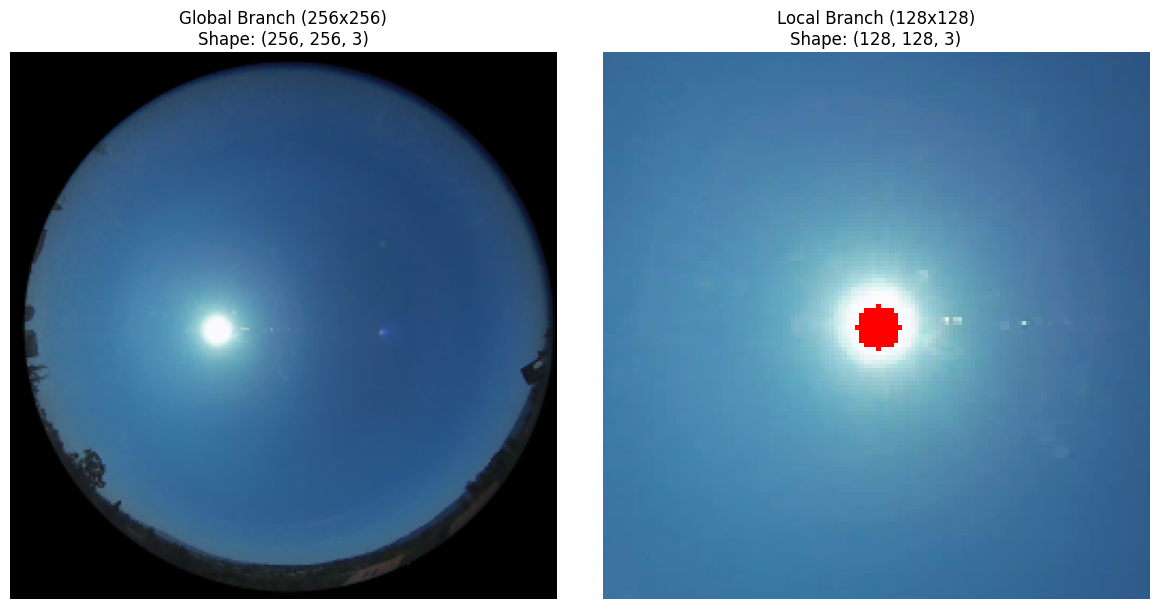

In [ ]:
def extract_dual_branch_images(img_bgr, sun_x, sun_y):
    """
    双分支视场重采样引擎：
    输入: 原始 2048x2048 BGR 图像, 太阳中心 X, 太阳中心 Y
    输出: 全局图(256x256 RGB), 局部图(128×128 RGB)
    """
    # ==========================================
    # 0. 绝对黑边清洗 (Mask)
    # ==========================================
    # 为了防止鱼眼镜头外围的暗灰色传感器噪声在裁切时形成诡异的纹理
    # 根据相机的理论圆心 (960, 928) 和半径 (928) 强行上一个纯黑掩膜
    # 计算真实圆心: (1053, 1024)
    # 真实半径: 1017 -> 安全内缩后: 992
    mask = np.zeros(img_bgr.shape[:2], dtype=np.uint8)
    cv2.circle(mask, (1053, 1024), 992, 255, -1)
    
    # 只有在圆形有效区域内的像素被保留，外围变成彻底的绝对黑 (0,0,0)
    img_clean = cv2.bitwise_and(img_bgr, img_bgr, mask=mask)
    
    # ==========================================
    # 1. 全局分支 (Global Branch)
    # 尺寸路线: 2048x2048 -> 256x256
    # ==========================================
    # 使用 cv2.INTER_AREA 极其平滑地浓缩全局云层信息，绝不产生锯齿摩尔纹
    global_img = cv2.resize(img_clean, (256, 256), interpolation=cv2.INTER_AREA)
    
    # 转换色彩空间为网络喜欢的 RGB，并锁死类型为 uint8
    global_img_rgb = cv2.cvtColor(global_img, cv2.COLOR_BGR2RGB).astype(np.uint8)
    
    # ==========================================
    # 2. 局部分支 (Local Branch)
    # 尺寸路线: 截取 768x768 -> 缩小至 128x128
    # ==========================================
    HUGE_CROP = 768
    HALF_CROP = HUGE_CROP // 2
    
    # 【核心安全设计】创建一个绝对安全的“纯黑垫底画布”
    canvas = np.zeros((HUGE_CROP, HUGE_CROP, 3), dtype=np.uint8)
    
    # 计算期望的裁剪坐标
    y_min, y_max = sun_y - HALF_CROP, sun_y + HALF_CROP
    x_min, x_max = sun_x - HALF_CROP, sun_x + HALF_CROP
    
    # 计算在 2048 原图上能“合法”切到的坐标边界 (防止负数或超出2048报错)
    img_h, img_w = img_clean.shape[:2]
    img_y_min, img_y_max = max(0, y_min), min(img_h, y_max)
    img_x_min, img_x_max = max(0, x_min), min(img_w, x_max)
    
    # 只要太阳还在图里（无论多偏），就把合法的部分“贴”到黑画布上
    if img_y_min < img_y_max and img_x_min < img_x_max:
        # 计算合法图像应该贴在画布的哪个位置
        canvas_y_min = img_y_min - y_min
        canvas_y_max = canvas_y_min + (img_y_max - img_y_min)
        canvas_x_min = img_x_min - x_min
        canvas_x_max = canvas_x_min + (img_x_max - img_x_min)
        
        # 像素级安全赋值！超出边界的部分自然就是黑色 Padding 了
        canvas[canvas_y_min:canvas_y_max, canvas_x_min:canvas_x_max] = img_clean[img_y_min:img_y_max, img_x_min:img_x_max]
        
    # 在拥有极宽广视野的画布上，平滑降采样到128x128
    local_img = cv2.resize(canvas, (128, 128), interpolation=cv2.INTER_AREA)
    local_img_rgb = cv2.cvtColor(local_img, cv2.COLOR_BGR2RGB).astype(np.uint8)
    
    return global_img_rgb, local_img_rgb

# ==========================================
# 🔍 内部测试代码 (真正联动 Cell 3)
# ==========================================
if __name__ == '__main__':
    import tarfile
    import os
    import datetime as dt
    
    # 请确保这里的文件名和你的真实路径一致
    test_tar = os.path.join(tar_folder, "2019_06_images_raw.tar") 
    
    if os.path.exists(test_tar):
        with tarfile.open(test_tar, "r") as tar:
            # 随便抽一张中午的图
            member = [m for m in tar.getmembers() if m.name.endswith('.jpg') and '1230' in m.name][0]
            
            # 解析真实时间
            filename = os.path.basename(member.name)
            time_str = filename.split('.')[0]
            curr_time = dt.datetime.strptime(time_str, '%Y%m%d%H%M%S')
            
            # 读取图像
            f = tar.extractfile(member)
            img_raw = cv2.imdecode(np.asarray(bytearray(f.read()), dtype=np.uint8), cv2.IMREAD_COLOR)
            
            # 🎯 关键修正：调用你在 Cell 3 写的终极插值定位函数！
            # (确保 get_smart_sun_position 在此 Cell 之前已经运行并存在于内存中)
            real_sun_x, real_sun_y = get_smart_sun_position(curr_time)
            
            print(f"当前时间: {curr_time}, 真实太阳中心坐标: ({real_sun_x}, {real_sun_y})")
            
            # 传入真实的坐标进行双分支提取
            global_out, local_out = extract_dual_branch_images(img_raw, real_sun_x, real_sun_y)
            
            # 可视化质检
            fig, axes = plt.subplots(1, 2, figsize=(12, 6))
            axes[0].imshow(global_out)
            axes[0].set_title(f"Global Branch (256x256)\nShape: {global_out.shape}", fontsize=12)
            axes[0].axis('off')
            
            # 在局部图上画个红点，验证是否严格居中
            cv2.circle(local_out, (64, 64), 5, (255, 0, 0), -1) 
            axes[1].imshow(local_out)
            axes[1].set_title(f"Local Branch (128x128)\nShape: {local_out.shape}", fontsize=12)
            axes[1].axis('off')
            
            plt.tight_layout()
            plt.show()

对局部图 (Local Branch 128x128) 来说： 确实有风险！因为裁剪框是跟着太阳动的，如果是早晨，树木被框进去，在网络看来树木就是在以极快的速度“后退”。

🎯 终极解法： 正如我们上一轮讨论的，树木只有在极其早晚的时候（太阳贴地平线）才会进入 768 的大框。而我们最终在提取数据时，会用 pv_value <= 0.1 或者 时间在 08:00 - 17:00 之外 的条件，把早晚的数据全部抛弃。当太阳升起后，768 的框里就全都是纯净的天空了，根本框不到树木！

###  Cell 5:文件构建

In [9]:
# ==========================================
# 0. 前置准备 (请确保前面的 Cell 已经运行)
# ==========================================
pv_output_all = pd.read_pickle(pv_data_path) # 加载 PV 数据
test_dates_only = set([dt.datetime.strptime(td, '%Y%m%d').date() if isinstance(td, str) else td.date() for td in test_dates])

# ==========================================
# 1. 核心辅助函数
# ==========================================
def find_time_within_pdseries(time_array, time_point):
    """原作者的极严苛对齐函数"""
    probable_idx = np.searchsorted(time_array, time_point)
    if probable_idx == len(time_array):
        return None   
    if time_array[probable_idx] == time_point: 
        return probable_idx
    else:
        return None

def append_to_dataset(dataset, data):
    """HDF5 动态追加"""
    dataset.resize(dataset.shape[0] + 1, axis=0)
    dataset[-1] = data

# ==========================================
# 2. 初始化 HDF5 与 记录列表
# ==========================================
times_trainval = []
times_test = []

print("🚀 启动终极 HDF5 内存流式榨汁机...")

with h5py.File(output_h5_path, 'w') as h5f:
    # 完美继承你的 Group 架构，并加上 lzf 压缩省空间
    for group_name in ['trainval', 'test']:
        grp = h5f.create_group(group_name)
        # 注意：这里严格遵循你为 PyTorch 设计的 (C, H, W) 格式
        grp.create_dataset('global_images_log', shape=(0, 3, 256, 256), maxshape=(None, 3, 256, 256), dtype='uint8', chunks=True, compression='lzf')
        grp.create_dataset('local_images_log', shape=(0, 3, 128, 128), maxshape=(None, 3, 128, 128), dtype='uint8', chunks=True, compression='lzf')
        grp.create_dataset('pv_log', shape=(0,), maxshape=(None,), dtype='float32')

    # 获取要处理的 tar 包
    tar_files = sorted([f for f in os.listdir(tar_folder) if f.endswith('.tar')])
    print(f"共发现 {len(tar_files)} 个压缩包等待处理。")

    # ==========================================
    # 3. 内存流式大循环 (无需解压落盘！)
    # ==========================================
    for tar_name in tar_files:
        tar_path = os.path.join(tar_folder, tar_name)
        print(f"\n--- 正在极速解析: {tar_name} ---")
        
        with tarfile.open(tar_path, "r") as tar:
            # 过滤出 jpg 文件并排序
            members = [m for m in tar.getmembers() if m.name.endswith('.jpg')]
            members.sort(key=lambda x: os.path.basename(x.name))
            
            # 用于“卡死帧检测”的缓存变量
            prev_img_gray = None
            current_day = None
            
            # 使用 tqdm 包装，享受你的进度条体验
            for m in tqdm(members, desc="处理进度", unit="帧"):
                filename = os.path.basename(m.name)
                
                try:
                    time_str = filename.split('.')[0]
                    curr_time = dt.datetime.strptime(time_str, '%Y%m%d%H%M%S')
                except ValueError:
                    continue 
                
                # --- 跨天重置卡死缓存 ---
                if curr_time.date() != current_day:
                    current_day = curr_time.date()
                    prev_img_gray = None
                
                # --- 物理过滤 1：早晚弱光剔除 (防止极端的黑边框) ---
                if curr_time.hour < 7 or (curr_time.hour == 7 and curr_time.minute < 30) or \
                   curr_time.hour > 17 or (curr_time.hour == 17 and curr_time.minute > 30):
                    continue
                
                # --- 物理过滤 2：严格 PV 对齐 ---
                pv_idx = find_time_within_pdseries(pv_output_all.index, curr_time)
                if pv_idx is None:
                    continue 
                pv_val = float(pv_output_all.iloc[pv_idx])
                
                # --- 💥 核心魔法：内存字节流直接转矩阵，硬盘 0 损耗 ---
                f = tar.extractfile(m)
                img_array = np.asarray(bytearray(f.read()), dtype=np.uint8)
                img_raw = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
                
                # --- 物理过滤 3：卡死帧剔除 ---
                curr_img_gray = cv2.cvtColor(img_raw, cv2.COLOR_BGR2GRAY)
                if prev_img_gray is not None:
                    # 如果画面全同，说明相机卡死，抛弃！
                    if np.sum(np.abs(curr_img_gray.astype(np.int16) - prev_img_gray.astype(np.int16))) == 0:
                        continue
                prev_img_gray = curr_img_gray
                
                # ==========================================
                # 🎯 提取双分支图像 (联动 Cell 3 和 Cell 4)
                # ==========================================
                # 1. 插值算精确坐标
                sun_x, sun_y = get_smart_sun_position(curr_time)
                
                # 2. 物理重采样与清洗
                img_g_rgb, img_l_rgb = extract_dual_branch_images(img_raw, sun_x, sun_y)
                
                # 3. 极其关键的 PyTorch 通道转置 (H, W, C) -> (C, H, W)
                img_g_pt = img_g_rgb.transpose(2, 0, 1)
                img_l_pt = img_l_rgb.transpose(2, 0, 1)
                
                # ==========================================
                # 归档写入
                # ==========================================
                is_test = curr_time.date() in test_dates_only
                target_group = 'test' if is_test else 'trainval'
                
                append_to_dataset(h5f[target_group]['global_images_log'], img_g_pt)
                append_to_dataset(h5f[target_group]['local_images_log'], img_l_pt)
                append_to_dataset(h5f[target_group]['pv_log'], pv_val)
                
                if is_test:
                    times_test.append(curr_time)
                else:
                    times_trainval.append(curr_time)

# ==========================================
# 4. 保存时间戳
# ==========================================
np.save(os.path.join(output_folder, 'times_trainval.npy'), np.array(times_trainval))
np.save(os.path.join(output_folder, 'times_test.npy'), np.array(times_test))

print("\n🎉 全部数据预处理完成！完美的 HDF5 与时间戳已生成，硬盘 0 碎片残留！")

🚀 启动终极 HDF5 内存流式榨汁机...
共发现 8 个压缩包等待处理。

--- 正在极速解析: 2019_01_images_raw.tar ---


处理进度:   0%|          | 0/3935 [00:00<?, ?帧/s]


--- 正在极速解析: 2019_02_images_raw.tar ---


处理进度:   0%|          | 0/4733 [00:00<?, ?帧/s]


--- 正在极速解析: 2019_05_images_raw.tar ---


...


--- 正在极速解析: 2019_09_images_raw.tar ---


处理进度:   0%|          | 0/25302 [00:00<?, ?帧/s]


--- 正在极速解析: 2019_10_images_raw.tar ---


处理进度:   0%|          | 0/26084 [00:00<?, ?帧/s]


🎉 全部数据预处理完成！完美的 HDF5 与时间戳已生成，硬盘 0 碎片残留！


In [ ]:
print("🛠️ 启动坐标事后修补程序...")

# 1. 读取刚才保存下来的时间戳
times_trainval = np.load(os.path.join(output_folder, 'times_trainval.npy'), allow_pickle=True)
times_test = np.load(os.path.join(output_folder, 'times_test.npy'), allow_pickle=True)

print(f"载入成功：Trainval {len(times_trainval)} 帧，Test {len(times_test)} 帧。")

# 2. 纯内存极速计算所有坐标
# (调用你之前的函数，这里纯数学计算，瞬间完成)
pos_trainval = np.array([get_smart_sun_position(t) for t in tqdm(times_trainval, desc="计算 Trainval 坐标")])
pos_test = np.array([get_smart_sun_position(t) for t in tqdm(times_test, desc="计算 Test 坐标")])

# 3. 施展 HDF5 的追加魔法 ('a' 模式：读写且不覆盖原数据)
with h5py.File(output_h5_path, 'a') as h5f:
    # 检查是否已经修补过，防止重复运行报错
    if 'sun_pos' in h5f['trainval']:
        del h5f['trainval']['sun_pos']
    if 'sun_pos' in h5f['test']:
        del h5f['test']['sun_pos']
        
    # 直接新建数据集并塞入算好的数组
    h5f['trainval'].create_dataset('sun_pos', data=pos_trainval, dtype='int32')
    h5f['test'].create_dataset('sun_pos', data=pos_test, dtype='int32')

print("🎉 补丁打入完毕！现在你的 HDF5 拥有完美的坐标信息了！")

🛠️ 启动坐标事后修补程序...
载入成功：Trainval 93483 帧，Test 7885 帧。


计算 Trainval 坐标:   0%|          | 0/93483 [00:00<?, ?it/s]

计算 Test 坐标:   0%|          | 0/7885 [00:00<?, ?it/s]

🎉 补丁打入完毕！现在你的 HDF5 拥有完美的坐标信息了！


早晨傍晚测试

极压测试 -> 时间: 06:08:00, 坐标: (328, 364)
极压测试 -> 时间: 06:18:00, 坐标: (327, 393)


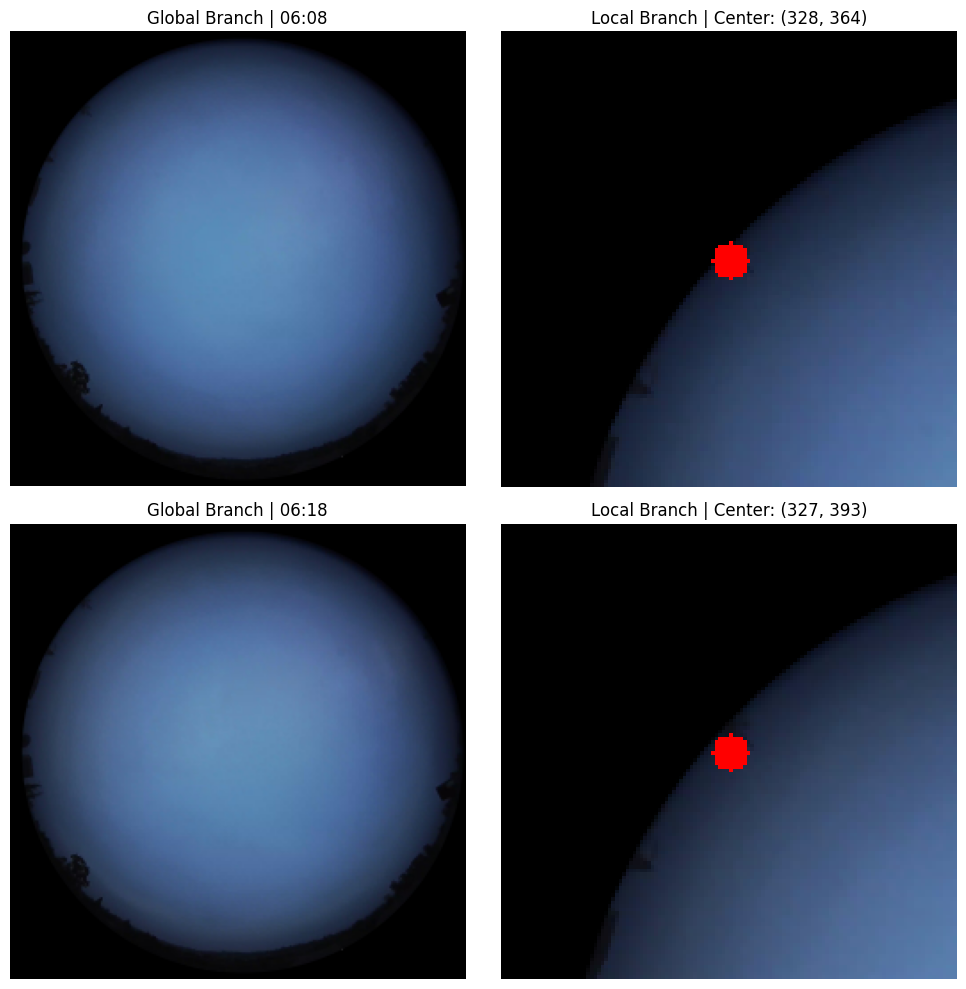

In [11]:
# ==========================================
# 🔍 边缘极限工况测试 (早晨与傍晚)
# ==========================================
if __name__ == '__main__':
    import tarfile
    import os
    import datetime as dt
    import matplotlib.pyplot as plt
    import cv2
    import numpy as np
    
    test_tar = os.path.join(tar_folder, "2019_06_images_raw.tar") 
    
    # 我们故意挑选早晨 08:00 和 傍晚 18:00 附近的时间
    # 夏至前后的 6 月，这两个时间的太阳极度靠边
    test_times = ['0800', '1800'] 
    
    if os.path.exists(test_tar):
        fig, axes = plt.subplots(len(test_times), 2, figsize=(10, 5 * len(test_times)))
        
        with tarfile.open(test_tar, "r") as tar:
            members = tar.getmembers()
            
            for i, target_time in enumerate(test_times):
                # 模糊匹配对应时间的图
                matched_members = [m for m in members if m.name.endswith('.jpg') and target_time in m.name]
                if not matched_members:
                    continue
                    
                member = matched_members[0] # 取第一张匹配的
                
                filename = os.path.basename(member.name)
                time_str = filename.split('.')[0]
                curr_time = dt.datetime.strptime(time_str, '%Y%m%d%H%M%S')
                
                f = tar.extractfile(member)
                img_raw = cv2.imdecode(np.asarray(bytearray(f.read()), dtype=np.uint8), cv2.IMREAD_COLOR)
                
                # 🎯 获取查表插值算出来的真实边缘坐标
                real_sun_x, real_sun_y = get_smart_sun_position(curr_time)
                print(f"极压测试 -> 时间: {curr_time.strftime('%H:%M:%S')}, 坐标: ({real_sun_x}, {real_sun_y})")
                
                # 双分支提取！这里是最容易越界崩溃的地方，看看能不能挺住
                global_out, local_out = extract_dual_branch_images(img_raw, real_sun_x, real_sun_y)
                
                # 画图
                axes[i, 0].imshow(global_out)
                axes[i, 0].set_title(f"Global Branch | {curr_time.strftime('%H:%M')}", fontsize=12)
                axes[i, 0].axis('off')
                
                cv2.circle(local_out, (64, 64), 5, (255, 0, 0), -1) 
                axes[i, 1].imshow(local_out)
                axes[i, 1].set_title(f"Local Branch | Center: ({real_sun_x}, {real_sun_y})", fontsize=12)
                axes[i, 1].axis('off')
                
        plt.tight_layout()
        plt.show()

重新打包一下h5（预分配模式），保证数据连续，提升读取速度。

In [13]:
import h5py
import numpy as np
from tqdm import tqdm

def repack_h5(old_h5_path, new_h5_path):
    with h5py.File(old_h5_path, 'r') as old_f, h5py.File(new_h5_path, 'w') as new_f:
        for group_name in ['trainval', 'test']:
            print(f"正在重整 {group_name} 分组...")
            old_grp = old_f[group_name]
            new_grp = new_f.create_group(group_name)
            
            # 获取总样本数
            N = old_grp['pv_log'].shape[0]
            
            # 1. 预分配空间 (重点：直接定死 N)
            print(f"预分配空间: N={N}")
            ds_g = new_grp.create_dataset('global_images_log', shape=(N, 3, 256, 256), dtype='uint8', compression='lzf')
            ds_l = new_grp.create_dataset('local_images_log', shape=(N, 3, 128, 128), dtype='uint8', compression='lzf')
            ds_p = new_grp.create_dataset('pv_log', shape=(N,), dtype='float32')
            ds_s = new_grp.create_dataset('sun_pos', shape=(N, 2), dtype='int32')
            
            # 2. 高速搬运 (分块读取能大幅提升 I/O 效率)
            # 我们一次搬 100 帧，比一帧一帧搬快得多
            chunk_size = 100
            for i in tqdm(range(0, N, chunk_size)):
                end = min(i + chunk_size, N)
                ds_g[i:end] = old_grp['global_images_log'][i:end]
                ds_l[i:end] = old_grp['local_images_log'][i:end]
                ds_p[i:end] = old_grp['pv_log'][i:end]
                ds_s[i:end] = old_grp['sun_pos'][i:end]

# 执行重整 (预计 10-20 分钟跑完)
repack_h5('output_folder/2019_dataset_dual.h5', 'output_folder/2019_dataset_dual_V2.h5')

正在重整 trainval 分组...
预分配空间: N=93483


100%|██████████| 935/935 [1:11:31<00:00,  4.59s/it]


正在重整 test 分组...
预分配空间: N=7885


100%|██████████| 79/79 [01:34<00:00,  1.20s/it]


改进后的索引重划脚本（无需重新跑 H5）
读取现有的全部时间点，并按照 80% 训练验证 / 20% 测试 的比例，严格按时间顺序切分：

In [7]:
import numpy as np
import os

times_trainval_path = r'E:\造数据集\output_folder\times_trainval.npy'
times_test_path = r'E:\造数据集\output_folder\times_test.npy'

# 1. 按照 HDF5 的物理追加顺序，还原时间戳列表
t_old_trainval = list(np.load(times_trainval_path, allow_pickle=True))
t_old_test = list(np.load(times_test_path, allow_pickle=True))

# 🌟 关键：按照 H5 的物理顺序合并（trainval在前，test在后）
# 这样 all_times[idx] 对应的时间，正好就是 H5 合并后第 idx 行的图像
all_times_physical_order = t_old_trainval + t_old_test

# 2. 现在的目标是：按【时间先后】重新切分，但要保持【物理索引】
# 我们给每个时间点打上它在 H5 里的“物理行号”标签
indexed_times = []
for i, t in enumerate(all_times_physical_order):
    indexed_times.append((t, i)) # (时间, 物理行号)

# 3. 按照时间排序
indexed_times.sort(key=lambda x: x[0])

# 4. 重新划分 8:2
split_idx = int(len(indexed_times) * 0.8)
train_val_pairs = indexed_times[:split_idx]
test_pairs = indexed_times[split_idx:]

# 5. 提取出重新划分后的时间（此时它们依然带着正确的物理行号）
new_times_trainval = [p[0] for p in train_val_pairs]
new_times_test = [p[0] for p in test_pairs]

# 6. 保存
np.save(times_trainval_path, np.array(new_times_trainval))
np.save(times_test_path, np.array(new_times_test))